In [4]:
import calliope
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Results are one folder up from notebooks/
results_dir = Path("../outputs")

files = {
    "without_transformer": results_dir / "without_transformer.nc",
    "with_transformer": results_dir / "with_transformer.nc",
    "grid_only": results_dir/"grid_only.nc"
}

models = {
    scenario: calliope.read_netcdf(path)
    for scenario, path in files.items()
}

pd.options.display.float_format = "{:,.3f}".format

In [6]:
def get_demand(model):
    demand = model.inputs.sink_use_equals

    if "timesteps" in demand.dims:
        demand = demand.sum("timesteps", skipna=True)

    return float(abs(demand.sum()))

total_demand = get_demand(models["without_transformer"])

demand_table = pd.DataFrame({
    "Value": [total_demand]
}, index=["Total electricity demand (kWh/year)"])

demand_table

,Value
Total electricity demand (kWh/year),"356,227.292"


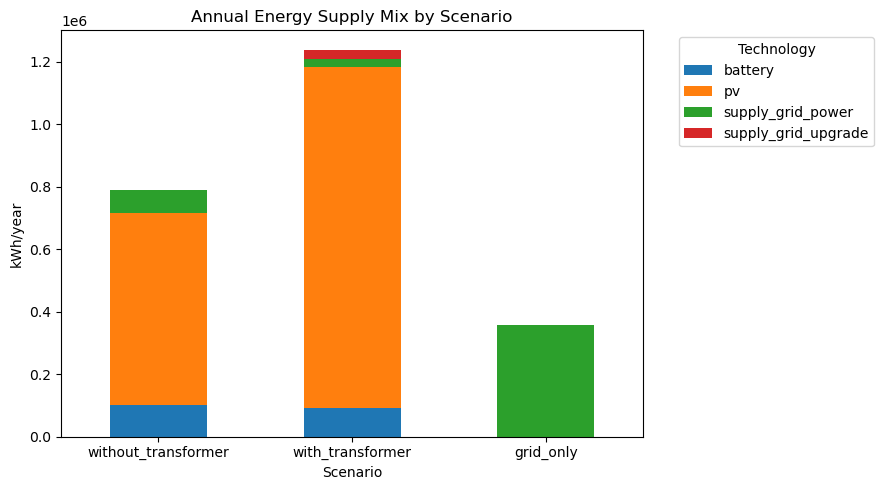

techs,battery,pv,supply_grid_power,supply_grid_upgrade
without_transformer,"100,963.523","613,606.908","75,619.504",0.000
with_transformer,"92,131.727","1,089,821.088","27,523.309","29,527.855"
grid_only,0.000,0.000,"355,762.934",0.000


In [7]:
def get_supply_by_tech(model):
    flow_out = model.results.flow_out

    base_tech = model.inputs.base_tech.to_series()
    selected_techs = base_tech[base_tech.isin(["supply", "storage"])].index.tolist()

    selected_techs = [t for t in selected_techs if t in flow_out.techs.values]

    flow_out = flow_out.sel(techs=selected_techs)

    if "timesteps" in flow_out.dims:
        flow_out = flow_out.sum("timesteps", skipna=True)

    dims_to_sum = [d for d in flow_out.dims if d != "techs"]
    if dims_to_sum:
        flow_out = flow_out.sum(dims_to_sum, skipna=True)

    return flow_out.to_series().dropna()

supply_df = pd.DataFrame({
    scenario: get_supply_by_tech(model)
    for scenario, model in models.items()
}).fillna(0).T

ax = supply_df.plot(kind="bar", stacked=True, figsize=(9, 5))
ax.set_ylabel("kWh/year")
ax.set_title("Annual Energy Supply Mix by Scenario")
ax.set_xlabel("Scenario")
plt.xticks(rotation=0)
plt.legend(title="Technology", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

supply_df

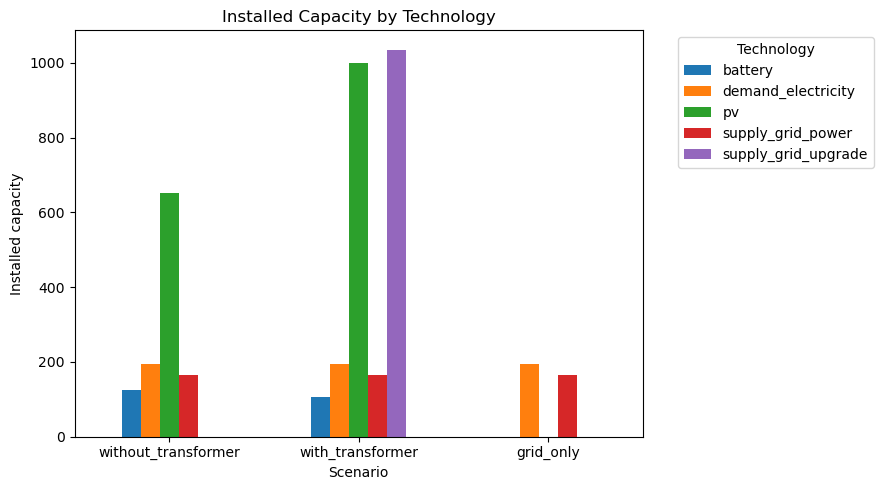

techs,battery,demand_electricity,pv,supply_grid_power,supply_grid_upgrade
without_transformer,125.659,193.000,651.140,165.000,0.000
with_transformer,105.424,193.000,999.000,165.000,"1,035.000"
grid_only,0.000,193.000,0.000,165.000,0.000


In [8]:
def get_installed_capacity(model):
    cap = model.results.flow_cap

    dims_to_sum = [d for d in cap.dims if d != "techs"]
    if dims_to_sum:
        cap = cap.sum(dims_to_sum, skipna=True)

    return cap.to_series().dropna()

capacity_df = pd.DataFrame({
    scenario: get_installed_capacity(model)
    for scenario, model in models.items()
}).fillna(0).T

ax = capacity_df.plot(kind="bar", figsize=(9, 5))
ax.set_ylabel("Installed capacity")
ax.set_title("Installed Capacity by Technology")
ax.set_xlabel("Scenario")
plt.xticks(rotation=0)
plt.legend(title="Technology", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

capacity_df

In [9]:
import pandas as pd



def get_pv_summary(model, pv_tech="pv"):
    results = model.results
    inputs = model.inputs

    if "flow_cap" in results and pv_tech in results.flow_cap.techs.values:
        pv_capacity = float(results.flow_cap.sel(techs=pv_tech).sum(skipna=True))
    else:
        pv_capacity = 0

    if "flow_out" in results and pv_tech in results.flow_out.techs.values:
        pv_actual_da = results.flow_out.sel(techs=pv_tech)

        if "timesteps" in pv_actual_da.dims:
            pv_actual_da = pv_actual_da.sum("timesteps", skipna=True)

        pv_actual = float(pv_actual_da.sum(skipna=True))
    else:
        pv_actual = 0

    if "source_use_max" in inputs and pv_tech in inputs.source_use_max.techs.values:
        pv_cf_da = inputs.source_use_max.sel(techs=pv_tech)

        if "timesteps" in pv_cf_da.dims:
            pv_cf_sum = float(
                abs(pv_cf_da.sum("timesteps", skipna=True).sum(skipna=True))
            )
        else:
            pv_cf_sum = float(abs(pv_cf_da.sum(skipna=True)))

        pv_potential = pv_capacity * pv_cf_sum
    else:
        pv_potential = None

    if pv_potential is not None:
        pv_curtailed = max(pv_potential - pv_actual, 0)
        pv_utilisation = pv_actual / pv_potential * 100 if pv_potential > 0 else 0
    else:
        pv_curtailed = None
        pv_utilisation = None

    return {
        "Installed PV capacity (kW)": pv_capacity,
        "Annual potential PV generation (kWh)": pv_potential,
        "Actual PV generation (kWh)": pv_actual,
        "Curtailed PV generation (kWh)": pv_curtailed,
        "PV utilisation (%)": pv_utilisation,
    }

pv_models = {
    scenario: model
    for scenario, model in models.items()
    if scenario != "grid_only"
}

pv_df = pd.DataFrame({
    scenario: get_pv_summary(model)
    for scenario, model in pv_models.items()
}).T

display(pv_df.round(2))

,Installed PV capacity (kW),Annual potential PV generation (kWh),Actual PV generation (kWh),Curtailed PV generation (kWh),PV utilisation (%)
without_transformer,651.140,"710,336.470","613,606.910","96,729.560",86.380
with_transformer,999.000,"1,089,821.090","1,089,821.090",0.000,100.000


In [10]:

def get_cost_summary(model):
    rows = {}

    for var in model.results.data_vars:
        if "cost" in var.lower():
            da = model.results[var]

            # Sum over all dimensions
            total = float(da.sum(skipna=True))

            rows[var] = total

    return rows

cost_df = pd.DataFrame({
    scenario: get_cost_summary(model)
    for scenario, model in models.items()
}).T

display(cost_df.round(3))

,cost_investment_purchase,cost_operation_variable,cost_investment_flow_cap,cost_investment_storage_cap,cost_investment,cost_investment_annualised,cost,min_cost_optimisation,systemwide_levelised_cost,total_levelised_cost
without_transformer,0.000,"6,016.097","475,903.515","111,794.795","587,698.310","42,924.010","48,940.107","48,940.107",0.440,0.049
with_transformer,"210,000.000","-27,306.030","716,167.866","101,856.164","1,028,024.030","74,043.793","46,737.763","46,737.763",1.250,0.024
grid_only,0.000,"113,844.139",0.000,0.000,0.000,0.000,"113,844.139","464,472,535.239",0.320,0.320


In [ ]:
import xarray as xr
import pandas as pd
from pathlib import Path
import numpy as np

results_dir = Path("../outputs")

files = {
    "without_transformer": results_dir / "without_transformer.nc",
    "with_transformer": results_dir / "with_transformer.nc",
    "grid_only": results_dir / "grid_only.nc",
}

def flatten_dataset(ds):
    rows = {}

    for var in ds.data_vars:
        da = ds[var]

        if da.dtype.kind in {"U", "S", "O"}:
            continue

        if "timesteps" in da.dims:
            da = da.sum("timesteps", skipna=True)

        # handle scalar variables
        if len(da.dims) == 0:
            rows[var] = float(da.values)
            continue

        series = da.to_series().dropna()

        for idx, value in series.items():
            if isinstance(idx, tuple):
                label = var + " | " + " | ".join(map(str, idx))
            else:
                label = var + " | " + str(idx)

            rows[label] = value

    return rows

input_tables = {}
output_tables = {}

for scenario, file in files.items():
    inputs = xr.open_dataset(file, group="inputs", engine="netcdf4")
    results = xr.open_dataset(file, group="results", engine="netcdf4")

    input_tables[scenario] = flatten_dataset(inputs)
    output_tables[scenario] = flatten_dataset(results)

inputs_df = pd.DataFrame(input_tables)
outputs_df = pd.DataFrame(output_tables)

display(inputs_df)

In [ ]:
display(outputs_df)

In [ ]:
with pd.ExcelWriter("calliope_results_summary.xlsx", engine="openpyxl") as writer:
    inputs_df.to_excel(writer, sheet_name="Inputs")
    outputs_df.to_excel(writer, sheet_name="Outputs")